   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.2 MB/s eta 0:00:00
Loading GloVe vectors... (first run takes ~30s)
[==================================================] 100.0% 66.0/66.0MB downloaded
Loaded.

Embedded 21 words, dim=50

Pair                     Category Match    Cosine Similarity
-----------------------------------------------------
dog / cat                same              0.922
france / germany         same              0.774
pizza / pasta            same              0.735
dog / pizza              different         0.493
france / sushi           different         -0.041


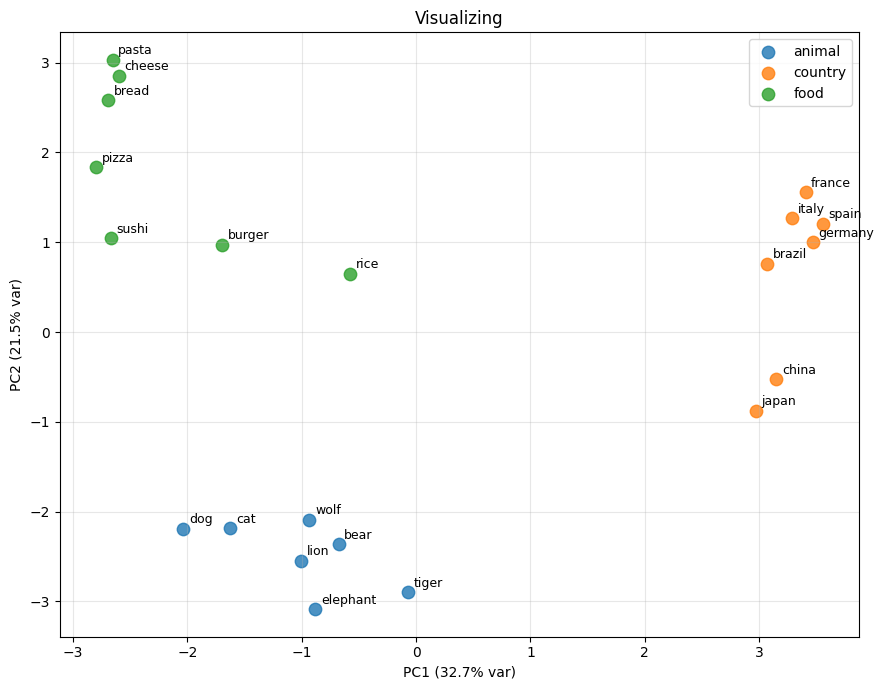

In [1]:
#cosine similarity and visualization
!pip install -q gensim scikit-learn matplotlib

import gensim.downloader as api
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
print("Loading GloVe vectors... (first run takes ~30s)")
model = api.load("glove-wiki-gigaword-50")
print("Loaded.\n")
categories = {
    "animal": ["dog", "cat", "lion", "tiger", "elephant", "wolf", "bear"],
    "country": ["france", "germany", "italy", "spain", "japan", "china", "brazil"],
    "food": ["pizza", "burger", "sushi", "pasta", "bread", "rice", "cheese"],
}

words, labels = [], []
for cat, wlist in categories.items():
    for w in wlist:
        if w in model:  # safety check
            words.append(w)
            labels.append(cat)

vectors = np.array([model[w] for w in words])
print(f"Embedded {len(words)} words, dim={vectors.shape[1]}\n")

pairs = [
    ("dog", "cat"),
    ("france", "germany"),
    ("pizza", "pasta"),
    ("dog", "pizza"),
    ("france", "sushi"),
]

print(f"{'Pair':<25}{'Category Match':<18}{'Cosine Similarity':<10}")
print("-" * 53)
for w1, w2 in pairs:
    v1, v2 = model[w1].reshape(1, -1), model[w2].reshape(1, -1)
    sim = cosine_similarity(v1, v2)[0][0]
    cat1 = next(c for c, ws in categories.items() if w1 in ws)
    cat2 = next(c for c, ws in categories.items() if w2 in ws)
    match = "same" if cat1 == cat2 else "different"
    print(f"{w1+' / '+w2:<25}{match:<18}{sim:.3f}")
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

color_map = {"animal": "tab:blue", "country": "tab:orange", "food": "tab:green"}
plt.figure(figsize=(9, 7))
for cat in categories:
    idx = [i for i, l in enumerate(labels) if l == cat]
    plt.scatter(coords[idx, 0], coords[idx, 1], label=cat,
                color=color_map[cat], s=80, alpha=0.8)

for i, w in enumerate(words):
    plt.annotate(w, (coords[i, 0], coords[i, 1]),
                 xytext=(4, 4), textcoords="offset points", fontsize=9)

plt.title("Visualizing")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Interpretation of plot:-
There is no overlap of the categories.
Food is more spread out(because of the cuisines)
